In [ ]:
from core.database import connect_to_database, fetch_data

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [10]:
conn = connect_to_database()
df_transaction = fetch_data(conn, type='transform')
conn.close()

In [11]:
df_transaction.head(2)

,id,description,distance,time,delay_time,waiting,hour,period,date,distance_bin,time_slot,condition_text,precip_mm_bin,wind_kph_bin,vis_km_bin,x_img,y_img
0,1,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,500,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Trung bình,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),436.28000000000003,78.0
1,2,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,400,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Trung bình,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),452.81600000000003,115.15199999999999


In [12]:
import pandas as pd

# Bước 1: Chuẩn bị dữ liệu

In [15]:
df_transaction['route'] = df_transaction["description"].str.replace("Từ ", "").str.strip()

df_transaction = df_transaction.dropna()  # Loại null nếu có
df_transaction

,id,description,distance,time,delay_time,waiting,hour,period,date,distance_bin,time_slot,condition_text,precip_mm_bin,wind_kph_bin,vis_km_bin,x_img,y_img,route
0,1,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,500,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Trung bình,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),436.28000000000003,78.0,Ngã Sáu Cộng Hòa đến An Dương Vương
1,2,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,400,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Trung bình,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),452.81600000000003,115.15199999999999,Ngã Sáu Cộng Hòa đến An Dương Vương
2,3,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,300,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Trung bình,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),469.35200000000003,152.30400000000003,Ngã Sáu Cộng Hòa đến An Dương Vương
3,4,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,200,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Gần,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),485.88800000000003,185.328,Ngã Sáu Cộng Hòa đến An Dương Vương
4,5,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,100,2025-07-19 08:19:00,357,Chờ chấp nhận được,8,Trưa,2025-07-19,Gần,11:00 - 12:00,Overcast,Không mưa (0),Gió mạnh (> 20),Trung bình (6 - 10),496.91200000000003,218.352,Ngã Sáu Cộng Hòa đến An Dương Vương
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11670,11671,Từ Vòng Xoay Trần Phú đến ĐHSP,400,2025-08-15 13:19:00,108,Chờ không đáng kể,13,Chiều,2025-08-15,Trung bình,16:00 - 17:00,Light rain,Mưa lớn (> 2.5),Gió mạnh (> 20),Trung bình (6 - 10),309.504,325.67999999999995,Vòng Xoay Trần Phú đến ĐHSP
11671,11672,Từ Vòng Xoay Trần Phú đến ĐHSP,300,2025-08-15 13:19:00,108,Chờ không đáng kể,13,Chiều,2025-08-15,Trung bình,16:00 - 17:00,Patchy light rain with thunder,Mưa lớn (> 2.5),Gió mạnh (> 20),Trung bình (6 - 10),348.088,309.168,Vòng Xoay Trần Phú đến ĐHSP
11672,11673,Từ Vòng Xoay Trần Phú đến ĐHSP,200,2025-08-15 13:19:00,108,Chờ không đáng kể,13,Chiều,2025-08-15,Gần,16:00 - 17:00,Light rain,Mưa lớn (> 2.5),Gió mạnh (> 20),Trung bình (6 - 10),392.18399999999997,292.656,Vòng Xoay Trần Phú đến ĐHSP
11673,11674,Từ Vòng Xoay Trần Phú đến ĐHSP,100,2025-08-15 13:19:00,0,Chờ không đáng kể,13,Chiều,2025-08-15,Gần,16:00 - 17:00,Patchy light rain with thunder,Mưa lớn (> 2.5),Gió mạnh (> 20),Trung bình (6 - 10),430.76800000000003,280.27200000000005,Vòng Xoay Trần Phú đến ĐHSP


In [17]:
import numpy as np
import random

transactions = df_transaction.apply(
    lambda row: [
        row["route"],
        row["period"],
        row["precip_mm_bin"],
        row["vis_km_bin"],
        row["wind_kph_bin"],
        row["waiting"]
    ],
    axis=1
).tolist()

sample_transactions = random.sample(transactions, 10)
unique_transactions = [list(t) for t in set(tuple(x) for x in transactions)]

print("Ví dụ 10 transaction ngẫu nhiên:")
print(np.array(sample_transactions))
print(f"Tổng cộng có: {len(transactions)} giao dịch," \
      f" trong đó có {len(unique_transactions)} giao dịch khác nhau đôi một")

Ví dụ 10 transaction ngẫu nhiên:
[['Vòng Xoay Trần Phú đến ĐHSP' 'Trưa' 'Không mưa (0)'
  'Trung bình (6 - 10)' 'Gió mạnh (> 20)' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Chiều' 'Mưa nhẹ (0 - 2.5)'
  'Trung bình (6 - 10)' 'Gió vừa (11 - 20)' 'Chờ không đáng kể']
 ['Ngã Sáu Cộng Hòa đến An Dương Vương' 'Trưa' 'Không mưa (0)'
  'Trung bình (6 - 10)' 'Gió mạnh (> 20)' 'Chờ chấp nhận được']
 ['Vòng Xoay Trần Phú đến ĐHSP' 'Chiều' 'Mưa nhẹ (0 - 2.5)'
  'Trung bình (6 - 10)' 'Gió vừa (11 - 20)' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Sáng' 'Không mưa (0)'
  'Trung bình (6 - 10)' 'Gió mạnh (> 20)' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Chiều' 'Không mưa (0)'
  'Trung bình (6 - 10)' 'Gió vừa (11 - 20)' 'Chờ không đáng kể']
 ['Cầu Nguyễn Văn Cừ đến An Dương Vương' 'Chiều' 'Không mưa (0)'
  'Trung bình (6 - 10)' 'Gió vừa (11 - 20)' 'Chờ không đáng kể']
 ['Ngã Sáu Cộng Hòa đến An Dương Vương' 'Sáng' 'Không mưa (0)'
  'Trung bình

# Bước 2: Chọn ngưỡng tham số (support và confidence)
**Support (Độ hỗ trợ):**
Tỉ lệ giao dịch có cả A và B. → Cho biết luật đó xuất hiện phổ biến hay hiếm.

**Confidence (Độ tin cậy):**
Xác suất mua B khi đã mua A. → Cho biết độ mạnh của mối quan hệ.


In [18]:
df_transaction['waiting'].unique()

array(['Chờ chấp nhận được', 'Chờ không đáng kể', 'Chờ lâu'], dtype=object)

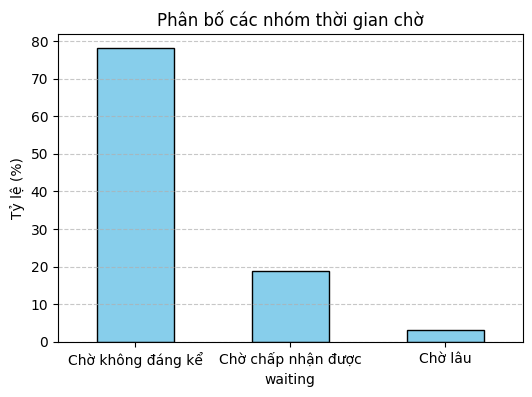

Tỷ lệ phần trăm các nhóm thời gian chờ:
waiting
Chờ không đáng kể     78.072539
Chờ chấp nhận được    18.849741
Chờ lâu                3.077720
Name: proportion, dtype: float64


In [19]:
import matplotlib.pyplot as plt

# Đếm tần suất từng nhóm thời gian chờ
waiting_counts = df_transaction['waiting'].value_counts(normalize=True) * 100

# Vẽ biểu đồ cột
plt.figure(figsize=(6,4))
waiting_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.ylabel("Tỷ lệ (%)")
plt.title("Phân bố các nhóm thời gian chờ")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Tỷ lệ phần trăm các nhóm thời gian chờ:")
print(waiting_counts)

📝 Biện luận lựa chọn tham số
**1. Support**

Nhóm “Chờ lâu” chỉ chiếm khoảng 4.6% dữ liệu. Nếu đặt ngưỡng `min_support` quá cao (ví dụ 0.1 = 10%), toàn bộ các luật liên quan đến “Chờ lâu” sẽ bị loại bỏ.

Nhóm “Chờ chấp nhận được” chiếm ~22.8%, nhóm này dễ đạt support cao hơn nên ít bị ảnh hưởng.

Nhóm “Chờ không đáng kể” chiếm đa số (72.6%), nên mọi luật liên quan tới nhóm này đều có support cao, nhưng có nguy cơ trở thành luật hiển nhiên (trivial rules).

👉 Vì vậy, để giữ được các luật quan trọng nhưng hiếm (liên quan tới “Chờ lâu”), ta nên đặt: `min_support ≈ 0.02`
  
Tương ứng với việc các luật cần xuất hiện ít nhất ~120 lần trong tổng 5967 giao dịch.


**2. Confidence**

Nếu đặt ≥0.7 thì toàn bộ các luật liên quan đến “Chờ lâu” sẽ biến mất.

Chọn ngưỡng 0.5 để vẫn giữ lại các luật quan trọng về hiện tượng hiếm.

Luật có confidence 0.5 nghĩa là: trong ít nhất một nửa số trường hợp antecedent xảy ra thì consequent cũng xảy ra.

👉 Đề xuất: `min_confidence ≈ 0.5`

In [26]:
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.5

# Bước 3: Tìm các itemsets phổ biến

In [27]:
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print("Top 5 itemsets phổ biến:")
print(frequent_itemsets.head(5))
print(f"5 Itemsets cuối cùng:\n {frequent_itemsets.tail(5)}")
print(f"\nTổng số lượng itemsets: {len(frequent_itemsets)}")

Top 5 itemsets phổ biến:
     support                                  itemsets
13  0.979689                     (Trung bình (6 - 10))
2   0.780725                       (Chờ không đáng kể)
47  0.769223  (Chờ không đáng kể, Trung bình (6 - 10))
7   0.666839                           (Không mưa (0))
82  0.662073      (Không mưa (0), Trung bình (6 - 10))
5 Itemsets cuối cùng:
       support                                           itemsets
565  0.010259  (Mưa nhẹ (0 - 2.5), Gió mạnh (> 20), Vòng Xoay...
704  0.010259  (Mưa nhẹ (0 - 2.5), Gió mạnh (> 20), Chờ không...
484  0.010259  (Mưa nhẹ (0 - 2.5), Chờ không đáng kể, Ngã Sáu...
714  0.010259  (Mưa nhẹ (0 - 2.5), Trung bình (6 - 10), Gió v...
783  0.010259  (Mưa nhẹ (0 - 2.5), Trung bình (6 - 10), Gió m...

Tổng số lượng itemsets: 790



Số lượng itemsets theo độ dài:
length
1     17
2     91
3    230
4    274
5    149
6     29
Name: count, dtype: int64


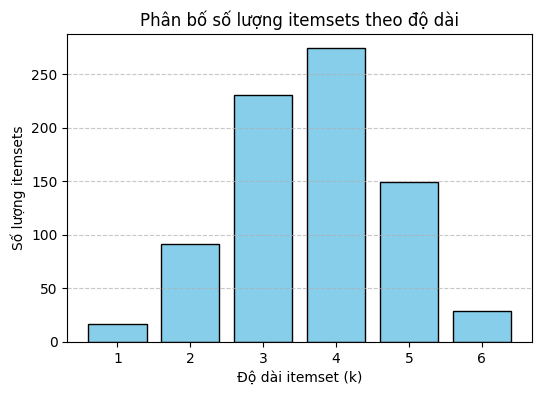

In [28]:
# Thêm cột 'length' = số phần tử trong itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Đếm số lượng itemsets theo độ dài
length_counts = frequent_itemsets['length'].value_counts().sort_index()
print("\nSố lượng itemsets theo độ dài:")
print(length_counts)

# Vẽ biểu đồ cột
plt.figure(figsize=(6,4))
plt.bar(length_counts.index, length_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Độ dài itemset (k)')
plt.ylabel('Số lượng itemsets')
plt.title('Phân bố số lượng itemsets theo độ dài')
plt.xticks(length_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
frequent_itemsets[frequent_itemsets['length'].isin([1])]

,support,itemsets,length
13,0.979689,(Trung bình (6 - 10)),1
2,0.780725,(Chờ không đáng kể),1
7,0.666839,(Không mưa (0)),1
6,0.587772,(Gió vừa (11 - 20)),1
15,0.440000,(Vòng Xoay Trần Phú đến ĐHSP),1
14,0.360104,(Trưa),1
11,0.329016,(Sáng),1
9,0.322798,(Mưa nhẹ (0 - 2.5)),1
4,0.320000,(Cầu Nguyễn Văn Cừ đến An Dương Vương),1
0,0.310881,(Chiều),1


# Bước 4. Sinh luật kết hợp

In [30]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
print("Các luật kết hợp:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Các luật kết hợp:
                            antecedents            consequents   support  \
0                   (Chờ không đáng kể)  (Trung bình (6 - 10))  0.769223   
1                 (Trung bình (6 - 10))    (Chờ không đáng kể)  0.769223   
2                       (Không mưa (0))  (Trung bình (6 - 10))  0.662073   
3                 (Trung bình (6 - 10))        (Không mưa (0))  0.662073   
4                   (Gió vừa (11 - 20))  (Trung bình (6 - 10))  0.567461   
5                 (Trung bình (6 - 10))    (Gió vừa (11 - 20))  0.567461   
6                       (Không mưa (0))    (Chờ không đáng kể)  0.526839   
7                   (Chờ không đáng kể)        (Không mưa (0))  0.526839   
8    (Không mưa (0), Chờ không đáng kể)  (Trung bình (6 - 10))  0.524041   
9  (Không mưa (0), Trung bình (6 - 10))    (Chờ không đáng kể)  0.524041   

   confidence      lift  
0    0.985267  1.005693  
1    0.785170  1.005693  
2    0.992852  1.013435  
3    0.675799  1.013435  
4    0.965444  

In [31]:
rules_high_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ lâu"})]
rules_medium_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ chấp nhận được"})]
rules_low_wait = rules[rules['consequents'].apply(lambda x: x == {"Chờ không đáng kể"})]

rules_high_wait = rules_high_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

rules_medium_wait = rules_medium_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

rules_low_wait = rules_low_wait.sort_values(
    by=["confidence", "support", "lift"],
    ascending=[False, False, False]
)

print(f"Tổng số luật cho thời gian chờ lâu (trên 600 giây): {len(rules_high_wait)}")
print(f"Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): {len(rules_medium_wait)}")
print(f"Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): {len(rules_low_wait)}")

Tổng số luật cho thời gian chờ lâu (trên 600 giây): 3
Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): 45
Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): 263


# Bước 5. Đánh giá luật

**Lift (Hệ số nâng đỡ):**
Đo xem luật có ý nghĩa thực sự không, bằng cách so sánh với trường hợp ngẫu nhiên.
- Lift = 1 → không có ý nghĩa
- Lift > 1 → A và B đi cùng nhau nhiều hơn ngẫu nhiên
- Lift < 1 → A và B ít đi cùng nhau

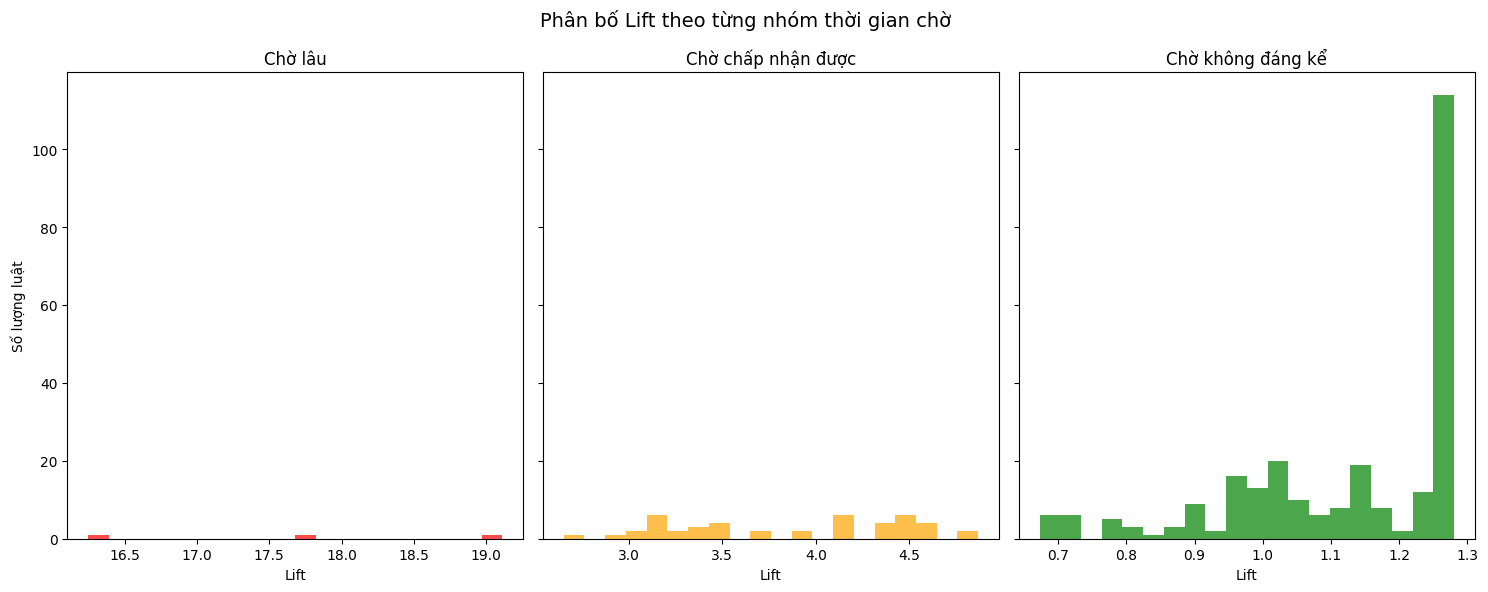

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)  # 1 hàng, 3 cột

# Histogram cho "Chờ lâu"
axes[0].hist(rules_high_wait['lift'], bins=20, color="red", alpha=0.7)
axes[0].set_title("Chờ lâu")
axes[0].set_xlabel("Lift")
axes[0].set_ylabel("Số lượng luật")

# Histogram cho "Chờ chấp nhận được"
axes[1].hist(rules_medium_wait['lift'], bins=20, color="orange", alpha=0.7)
axes[1].set_title("Chờ chấp nhận được")
axes[1].set_xlabel("Lift")

# Histogram cho "Chờ không đáng kể"
axes[2].hist(rules_low_wait['lift'], bins=20, color="green", alpha=0.7)
axes[2].set_title("Chờ không đáng kể")
axes[2].set_xlabel("Lift")

plt.suptitle("Phân bố Lift theo từng nhóm thời gian chờ", fontsize=14)
plt.tight_layout()
plt.show()

Chọn `min_lift  ≈ 1.3` do quan sát biểu đồ "Phân bố lift theo nhóm chờ không đáng kể" cho thấy lift >= 1.3 thuộc phạm vi chấp nhận được để chắn rằng những luật này không phát sinh từ ngẫu nhiên

In [33]:
MIN_LIFT = 1.2

rules_high_wait_lift = rules_high_wait[rules_high_wait['lift'] >= MIN_LIFT]
rules_medium_wait_lift = rules_medium_wait[rules_medium_wait['lift'] >= MIN_LIFT]
rules_low_wait_lift = rules_low_wait[rules_low_wait['lift'] >= MIN_LIFT]


print(f"Tổng số luật cho thời gian chờ lâu (trên 600 giây): {len(rules_high_wait_lift)}")
print(f"Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): {len(rules_medium_wait_lift)}")
print(f"Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): {len(rules_low_wait_lift)}")

Tổng số luật cho thời gian chờ lâu (trên 600 giây): 3
Tổng số luật cho thời gian chờ chấp nhận được (từ 300 giây đến 600 giây): 45
Tổng số luật cho thời gian chờ không đáng kể (dưới 300 giây): 128


# Bước 6. Ứng dụng

Chọn ra top 10 luật cho mỗi nhóm thời gian chờ

In [34]:
TOP_K = 10

In [35]:
# Top 5 luật "Chờ lâu"
top5_high = rules_high_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Top 5 luật "Chờ chấp nhận được"
top5_medium = rules_medium_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Top 5 luật "Chờ không đáng kể"
top5_low = rules_low_wait.head(TOP_K)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print(f"🔴 Top {TOP_K} luật với hậu quả - Chờ lâu:")
print(top5_high, "\n")

print(f"🟠 Top {TOP_K} luật với hậu quả - Chờ chấp nhận được:")
print(top5_medium, "\n")

print(f"🟢 Top {TOP_K} luật với hậu quả - Chờ không đáng kể:")
print(top5_low)

🔴 Top 10 luật với hậu quả - Chờ lâu:
                                            antecedents consequents   support  \
1978  (Mưa nhẹ (0 - 2.5), Trưa, Ngã Sáu Cộng Hòa đến...   (Chờ lâu)  0.012435   
1907  (Mưa nhẹ (0 - 2.5), Trưa, Ngã Sáu Cộng Hòa đến...   (Chờ lâu)  0.014301   
2009  (Mưa nhẹ (0 - 2.5), Trưa, Ngã Sáu Cộng Hòa đến...   (Chờ lâu)  0.011813   

      confidence       lift  
1978    0.588235  19.112696  
1907    0.547619  17.793009  
2009    0.500000  16.245791   

🟠 Top 10 luật với hậu quả - Chờ chấp nhận được:
                                            antecedents           consequents  \
1771  (Không mưa (0), Trung bình (6 - 10), Gió vừa (...  (Chờ chấp nhận được)   
1780  (Không mưa (0), Ngã Sáu Cộng Hòa đến An Dương ...  (Chờ chấp nhận được)   
1470  (Sáng, Gió mạnh (> 20), Ngã Sáu Cộng Hòa đến A...  (Chờ chấp nhận được)   
1485  (Sáng, Ngã Sáu Cộng Hòa đến An Dương Vương, Gi...  (Chờ chấp nhận được)   
1080  (Không mưa (0), Ngã Sáu Cộng Hòa đến An Dương ...  (Chờ c

In [ ]:
output_file = "Top10_rules_each_group.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for label, df in [
        ("Chờ lâu", top5_high),
        ("Chờ chấp nhận được", top5_medium),
        ("Chờ không đáng kể", top5_low)
    ]:
        f.write(f"\n==========================================\n")
        f.write(f"🔹 Nhóm hậu quả: {label}\n")
        f.write("=============================================\n\n")

        for _, row in df.iterrows():
            f.write(f"Hậu quả (consequents): {', '.join(list(row['consequents']))}\n")
            f.write(f"Các tác nhân (antecedents): {', '.join(list(row['antecedents']))}\n")
            f.write(f"Độ phổ biến (support): {row['support']:.4f}\n")
            f.write(f"Độ tin cậy (confidence): {row['confidence']:.4f}\n")
            f.write(f"Độ phụ thuộc (lift): {row['lift']:.4f}\n")
            f.write("----------------------------------------\n")

print(f"✅ Đã lưu kết quả vào file: {output_file}")

✅ Đã lưu kết quả vào file: API/Top10_rules_each_group.txt
